# Transfer Learning dla Computer Vision

W rozległym i zawiłym krajobrazie głębokiego uczenia się, rozpoczęcie pracy może często wydawać się monumentalnym zadaniem. Na szczęście dzięki **torchvision.models** PyTorch nie trzeba wymyślać koła na nowo. Ten podmoduł zapewnia bogatą bibliotekę wstępnie zbudowanych i wytrenowanych modeli sieci neuronowych, usprawniając proces zarówno dla programistów, jak i badaczy. Podczas gdy modele te mogą być wdrażane „po wyjęciu z pudełka” do szybkich zadań, mogą być również precyzyjnie dostrojone struktury fundamentalne dla określonych aplikacji, oferując wszechstronność dla szerokiego spektrum zadań. Szczególnie w dziedzinie przetwarzania obrazu, torchvision.models prezentuje imponującą gamę - od klasycznych architektur konwolucyjnych, takich jak AlexNet i VGG, po bardziej współczesne struktury, takie jak ResNets, DenseNets i MobileNets. W tej sekcji skupimy się przede wszystkim na modelach opartych na obrazach. Aby wyjaśnić ten proces, zagłębimy się w praktyczny przykład, który wykorzystuje **models.resnet50** do stworzenia klasyfikatora obrazów.

Zaczniemy od użycia wstępnie zbudowanej sieci neuronowej ResNet50.  Model zostanie załadowany i pozwoli na klasyfikację prostych obrazów.

In [ ]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import requests
from PIL import Image
from io import BytesIO
from IPython.display import display

IMAGE_WIDTH = 224
IMAGE_HEIGHT = 224
IMAGE_CHANNELS = 3

# Załaduj wstępnie wytrenowany model ResNet i ustaw tryb oceny
model = models.resnet50(weights='ResNet50_Weights.IMAGENET1K_V1').to(device)

Zanim zagłębimy się w mechanikę korzystania z modelu, konieczne jest ustanowienie potoku wstępnego przetwarzania obrazu. Potok przetwarzania wstępnego zapewnia, że obrazy wprowadzane do sieci neuronowej mają optymalny format, rozmiar i normalizację dla wybranego modelu. Oto podział tego, co pociąga za sobą nasz potok przetwarzania wstępnego:

**Resize(256)** Ta funkcja zmienia rozmiar najkrótszej krawędzi obrazu do 256 pikseli, zachowując proporcje oryginalnego obrazu. Celem jest standaryzacja rozmiaru obrazu przy jednoczesnym zachowaniu jego zawartości.

**CenterCrop(IMAGE_WIDTH)** Po zmianie rozmiaru obraz może nie mieć jednolitego rozmiaru dla sieci neuronowej. Używając CenterCrop, wyodrębniamy środkową część obrazu o szerokości i wysokości równej IMAGE_WIDTH. Ten krok zapewnia, że wszystkie przetworzone obrazy będą miały spójny rozmiar, odpowiedni dla naszej sieci neuronowej.

* Sieci neuronowe w PyTorch oczekują danych wejściowych w postaci tensorów. Funkcja ToTensor() pobiera obraz PIL (lub tablicę NumPy) i konwertuje go na tensor PyTorch. Ponadto skaluje wartości pikseli z zakresu [0, 255] (standard dla danych obrazu) do zakresu zmiennoprzecinkowego [0.0, 1.0].

* Normalize(mean, std)** Normalizacja danych wejściowych jest kluczowa dla prawidłowego uczenia sieci neuronowych. Używając predefiniowanych wartości średniej i odchylenia standardowego, funkcja ta zapewnia, że nasze dane obrazu są zgodne ze „znormalizowanym” formatem, który okazał się skuteczny w przypadku wstępnie wytrenowanych modeli. Te konkretne średnie i standardowe wartości

In [ ]:
# Define preprocessing pipeline for the image
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_WIDTH),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

Włączenie tego potoku zapewnia, że każdy obraz wprowadzony do naszej sieci neuronowej, niezależnie od jego oryginalnego rozmiaru, formatu lub skali, zostanie odpowiednio przekształcony i znormalizowany, przygotowując grunt pod spójne i dokładne prognozy.

Aby kontynuować klasyfikację obrazu, kluczowe znaczenie ma zrozumienie danych wyjściowych naszego modelu. Dane wyjściowe modeli takich jak resnet50 z torchvision.models, po wstępnym przeszkoleniu na ImageNet, to zazwyczaj 1000-wymiarowy wektor. Każdy wymiar odpowiada prawdopodobieństwu przynależności obrazu do określonej klasy ze zbioru danych ImageNet.

Pojawia się intuicyjne pytanie: dlaczego podczas pracy z PyTorch pozyskujemy etykiety klas z witryny TensorFlow? Powód jest pragmatyczny. Zbiór danych ImageNet, zawierający 1000 klas, jest standardowym zbiorem danych wykorzystywanym do trenowania modeli głębokiego uczenia w różnych frameworkach, w tym zarówno TensorFlow, jak i PyTorch. Etykiety i ich odpowiednie indeksy pozostają spójne na tych platformach. Ponieważ TensorFlow wygodnie udostępnił plik JSON z tym mapowaniem w swojej pamięci masowej, jest to łatwo dostępne i niezawodne źródło do pobierania tych etykiet, niezależnie od frameworka, z którym pracujesz.

Przeanalizujmy dostarczony kod:

**IMAGE_NET_CLASSES** Jest to adres URL wskazujący na lokalizację, w której TensorFlow przechowuje indeks klas ImageNet w formacie JSON.

* Używamy funkcji **requests.get()** do pobrania danych JSON z podanego adresu URL. Metoda .json() następnie analizuje te dane, w wyniku czego powstaje plik

In [ ]:
# Load the ImageNet class names
IMAGE_NET_CLASSES = 'https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json'
class_idx = requests.get(IMAGE_NET_CLASSES).json()
index_class = {int(k): v[-1] for k, v in class_idx.items()}

Pod koniec tego procesu jesteśmy wyposażeni w słownik, który pomoże w tłumaczeniu danych wyjściowych sieci neuronowej na czytelne dla człowieka nazwy klas, umożliwiając intuicyjną i znaczącą interpretację przewidywań modelu.

Następnie tworzymy funkcję, która klasyfikuje obraz pod dowolnym adresem URL.

In [ ]:
def classify_image(url):
    model.eval()
    # Download the image from the URL
    response = requests.get(url)
    image = Image.open(BytesIO(response.content))
    image = image.resize((IMAGE_WIDTH, IMAGE_HEIGHT), Image.Resampling.LANCZOS)
    display(image)

    # Preprocess the image and prepare it for the model
    image_tensor = preprocess(image).unsqueeze(0).to(device)  # Add batch dimension

    # Get predictions from the model
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = (
            torch.nn.functional.softmax(outputs, dim=1)[0] * 100
        )  # Convert logits to probabilities
        top5_prob, top5_idx = probabilities.topk(5)

    # Print the top 5 predictions
    print("Top 5 Predictions:")
    for i in range(5):
        print(f"{i+1}. {index_class[top5_idx[i].item()]}: {top5_prob[i].item():.2f}%")

Zobaczymy, jak działa kalsyfikacja.

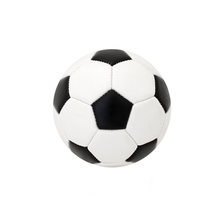

Top 5 Predictions:
1. soccer_ball: 89.90%
2. honeycomb: 7.14%
3. whistle: 0.61%
4. digital_clock: 0.27%
5. golf_ball: 0.20%


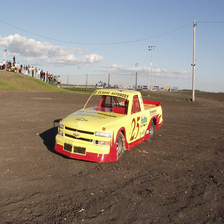

Top 5 Predictions:
1. racer: 80.54%
2. sports_car: 6.28%
3. pickup: 4.36%
4. tow_truck: 2.68%
5. car_wheel: 1.95%


In [ ]:
ROOT = "https://data.heatonresearch.com/data/t81-558/images/"

classify_image(ROOT+"soccer_ball.jpg")
classify_image(ROOT+"race_truck.jpg")

In [ ]:
import os
os.chdir("/content")

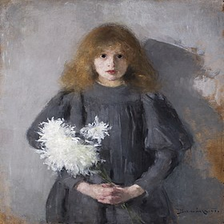

In [ ]:

image=Image.open('Olga.jpg')
image = image.resize((IMAGE_WIDTH, IMAGE_HEIGHT), Image.Resampling.LANCZOS)
display(image)


In [ ]:
def classify_image(path_or_url):
    model.eval()
    # Check if the input is a URL or a local path
    if path_or_url.startswith("http"):
        # Download the image from the URL
        response = requests.get(path_or_url)
        image = Image.open(BytesIO(response.content))
    else:
        # Open the image directly from the local path
        image = Image.open(path_or_url)
    image = image.resize((IMAGE_WIDTH, IMAGE_HEIGHT), Image.Resampling.LANCZOS)
    display(image)
       # Preprocess the image and prepare it for the model
    image_tensor = preprocess(image).unsqueeze(0).to(device)  # Add batch dimension

    # Get predictions from the model
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = (
            torch.nn.functional.softmax(outputs, dim=1)[0] * 100
        )  # Convert logits to probabilities
        top5_prob, top5_idx = probabilities.topk(5)

    # Print the top 5 predictions
    print("Top 5 Predictions:")
    for i in range(5):
        print(f"{i+1}. {index_class[top5_idx[i].item()]}: {top5_prob[i].item():.2f}%")

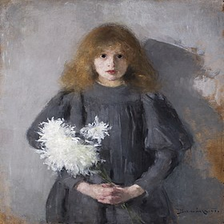

Top 5 Predictions:
1. feather_boa: 45.58%
2. poncho: 22.33%
3. cloak: 7.19%
4. wig: 4.22%
5. fur_coat: 2.19%


In [ ]:
ROOT = "/content/"
classify_image(ROOT+"Olga.jpg")